# MMM — Results
### Scored against the answer key

Every number below is compared to the truth that generated the data. No real
engagement can do this, which is the whole reason the dataset was simulated
(D13) after three real candidates each failed on identification.

**Read `05-analysis-plan.md` first.** It was committed before any model existed,
so nothing here was chosen after seeing results.

| # | Question |
|---|---|
| 1 | Did the model get the ranking right? |
| 2 | How wrong are the levels? |
| 3 | Did it recover carryover? |
| 4 | Did it find the planted null? |
| 5 | Does the decision rule permit a recommendation? |
| 6 | How much did the control choice matter? |

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt

SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2df"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": .8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "normal",
    "axes.titlelocation": "left", "figure.dpi": 110, "lines.linewidth": 2,
})
def tidy(ax, title=None, sub=None, ylab=None):
    if title: ax.set_title(title, pad=16 if sub else 6)
    if sub: ax.text(0, 1.015, sub, transform=ax.transAxes, fontsize=8.5, color=INK2)
    if ylab: ax.set_ylabel(ylab)
    ax.set_axisbelow(True); ax.grid(axis="x", visible=False); return ax

R = json.load(open("../data/simulated/model_results.json"))
T = json.load(open("../data/simulated/truth/parameters.json"))["channels"]
CH = ["linear_tv", "meta_social", "youtube", "ctv", "search_brand", "amazon_retail"]
LABEL = {"linear_tv": "Linear TV", "meta_social": "Meta social", "youtube": "YouTube",
         "ctv": "CTV", "search_brand": "Branded search", "amazon_retail": "Amazon retail"}

W = R["with_control"]
d = pd.DataFrame([{
    "channel": LABEL[c],
    "true_mroi": T[c]["true_marginal_roi"], "est_mroi": W["estimates"][c]["mroi"],
    "lo": W["estimates"][c]["mroi_lo"], "hi": W["estimates"][c]["mroi_hi"],
    "true_theta": T[c]["theta"], "est_theta": W["params"][c]["theta"],
    "share": T[c]["budget_share"],
} for c in CH])
print(f"bootstrap replicates: {W['n_boot']} | R2 with control {W['r2']:.4f} "
      f"| without {R['without_control']['r2']:.4f}")
d.round(3)

bootstrap replicates: 120 | R2 with control 0.8248 | without 0.8202


,channel,true_mroi,est_mroi,lo,hi,true_theta,est_theta,share
0,Linear TV,1.199,1.506,0.293,2.835,0.70,0.628,0.28
1,Meta social,2.393,5.336,2.109,8.969,0.40,0.689,0.18
2,YouTube,2.162,3.023,1.461,5.260,0.45,0.000,0.16
3,CTV,3.628,7.540,3.327,14.921,0.55,0.586,0.14
4,Branded search,0.000,5.139,0.644,10.926,0.10,0.721,0.12
5,Amazon retail,1.674,0.351,0.000,6.797,0.25,0.633,0.12


## 1. Did the model get the ranking right?

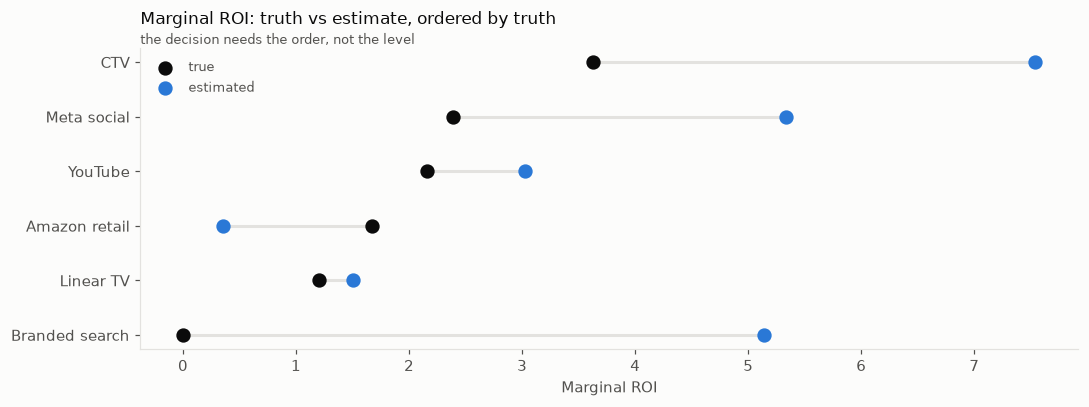

rank correlation (Spearman): +0.600
highest true mROI : CTV
highest est  mROI : CTV
lowest  true mROI : Branded search
lowest  est  mROI : Amazon retail


In [2]:
o = d.sort_values("true_mroi", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 3.8))
yv = np.arange(len(o))
ax.hlines(yv, o.true_mroi, o.est_mroi, color=GRID, linewidth=2, zorder=1)
ax.scatter(o.true_mroi, yv, s=70, color=INK, zorder=3, label="true")
ax.scatter(o.est_mroi, yv, s=70, color=BLUE, zorder=3, label="estimated")
ax.set_yticks(yv); ax.set_yticklabels(o.channel); ax.invert_yaxis()
ax.legend(frameon=False, fontsize=8.5, labelcolor=INK2)
ax.grid(axis="y", visible=False)
tidy(ax, "Marginal ROI: truth vs estimate, ordered by truth",
     "the decision needs the order, not the level", "")
ax.set_xlabel("Marginal ROI"); plt.tight_layout(); plt.show()

from scipy.stats import spearmanr
rho = spearmanr(d.true_mroi, d.est_mroi).statistic
print(f"rank correlation (Spearman): {rho:+.3f}")
print(f"highest true mROI : {d.loc[d.true_mroi.idxmax(),'channel']}")
print(f"highest est  mROI : {d.loc[d.est_mroi.idxmax(),'channel']}")
print(f"lowest  true mROI : {d.loc[d.true_mroi.idxmin(),'channel']}")
print(f"lowest  est  mROI : {d.loc[d.est_mroi.idxmin(),'channel']}")

**Your read:**



## 2. How wrong are the levels?

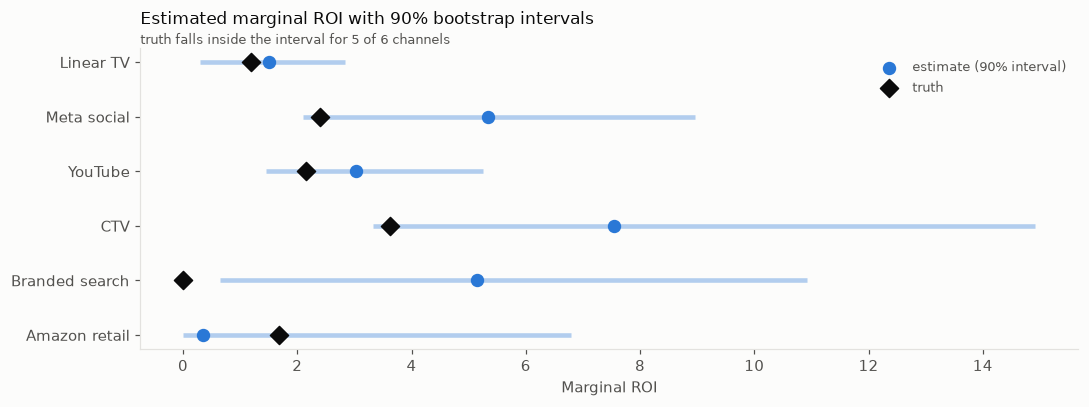

       channel  true_mroi  est_mroi   lo    hi  ratio
     Linear TV       1.20      1.51 0.29  2.84   1.26
   Meta social       2.39      5.34 2.11  8.97   2.23
       YouTube       2.16      3.02 1.46  5.26   1.40
           CTV       3.63      7.54 3.33 14.92   2.08
Branded search       0.00      5.14 0.64 10.93    NaN
 Amazon retail       1.67      0.35 0.00  6.80   0.21


In [3]:
fig, ax = plt.subplots(figsize=(10, 3.8))
yv = np.arange(len(d))
ax.hlines(yv, d.lo, d.hi, color=BLUE, linewidth=3, alpha=.35)
ax.scatter(d.est_mroi, yv, s=60, color=BLUE, zorder=3, label="estimate (90% interval)")
ax.scatter(d.true_mroi, yv, s=70, color=INK, marker="D", zorder=4, label="truth")
ax.set_yticks(yv); ax.set_yticklabels(d.channel); ax.invert_yaxis()
ax.legend(frameon=False, fontsize=8.5, labelcolor=INK2); ax.grid(axis="y", visible=False)
covered = int(((d.true_mroi >= d.lo) & (d.true_mroi <= d.hi)).sum())
tidy(ax, "Estimated marginal ROI with 90% bootstrap intervals",
     f"truth falls inside the interval for {covered} of {len(d)} channels", "")
ax.set_xlabel("Marginal ROI"); plt.tight_layout(); plt.show()

d["ratio"] = d.est_mroi / d.true_mroi.replace(0, np.nan)
print(d[["channel", "true_mroi", "est_mroi", "lo", "hi", "ratio"]].round(2).to_string(index=False))

**Your read:**



## 3. Did it recover carryover?

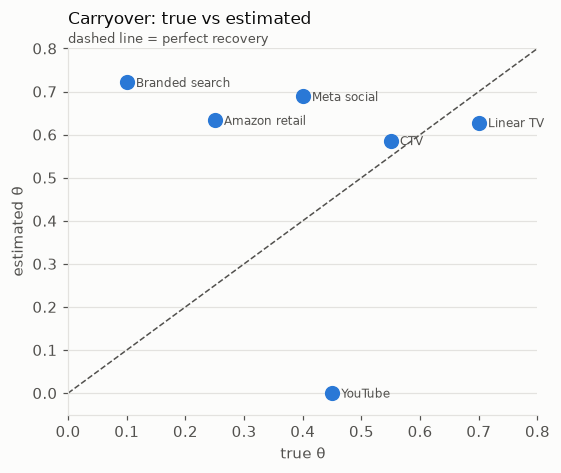

within 0.10 of truth: 2 of 6 channels
       channel  true_theta  est_theta  abs_err
     Linear TV        0.70       0.63     0.07
   Meta social        0.40       0.69     0.29
       YouTube        0.45       0.00     0.45
           CTV        0.55       0.59     0.04
Branded search        0.10       0.72     0.62
 Amazon retail        0.25       0.63     0.38


In [4]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.plot([0, .8], [0, .8], color=INK2, linestyle="--", linewidth=1)
ax.scatter(d.true_theta, d.est_theta, s=80, color=BLUE, zorder=3)
for _, r in d.iterrows():
    ax.annotate(r.channel, (r.true_theta, r.est_theta), fontsize=8,
                color=INK2, xytext=(6, -3), textcoords="offset points")
ax.set_xlim(0, .8); ax.set_ylim(-.05, .8)
tidy(ax, "Carryover: true vs estimated", "dashed line = perfect recovery", "estimated θ")
ax.set_xlabel("true θ"); plt.tight_layout(); plt.show()

err = (d.est_theta - d.true_theta).abs()
print(f"within 0.10 of truth: {int((err<=.10).sum())} of {len(d)} channels")
print(d[["channel", "true_theta", "est_theta"]].assign(abs_err=err.round(2)).round(2).to_string(index=False))

**Your read:**



## 4. Did it find the planted null?
Branded search was built with a true effect of **exactly zero** — the
incrementality test. A model that invents an effect here is disqualified under
the abandon criteria in `05` (D22).

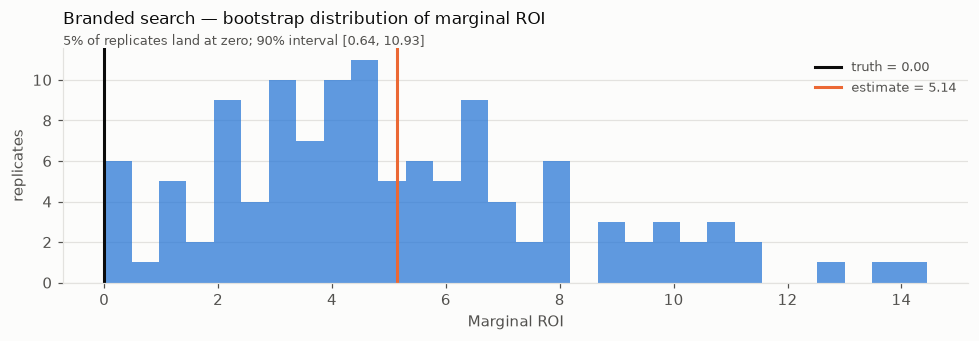

point estimate      : 5.14   (truth 0.00)
90% interval        : [0.64, 10.93]
interval excludes 0 : True

D22 abandon criterion — 'branded search returns a confidently positive ROI':
  TRIGGERED


In [5]:
bs = d[d.channel == "Branded search"].iloc[0]
draws = np.array(W["draws"]["search_brand"])
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(draws, bins=30, color=BLUE, alpha=.75)
ax.axvline(0, color=INK, linewidth=2, label="truth = 0.00")
ax.axvline(bs.est_mroi, color=ORANGE, linewidth=2, label=f"estimate = {bs.est_mroi:.2f}")
ax.legend(frameon=False, fontsize=8.5, labelcolor=INK2); ax.grid(axis="x", visible=False)
share_at_zero = float((draws <= 0.001).mean())
tidy(ax, "Branded search — bootstrap distribution of marginal ROI",
     f"{share_at_zero:.0%} of replicates land at zero; 90% interval "
     f"[{bs.lo:.2f}, {bs.hi:.2f}]", "replicates")
ax.set_xlabel("Marginal ROI"); plt.tight_layout(); plt.show()

print(f"point estimate      : {bs.est_mroi:.2f}   (truth 0.00)")
print(f"90% interval        : [{bs.lo:.2f}, {bs.hi:.2f}]")
print(f"interval excludes 0 : {bool(bs.lo > 0)}")
print()
print("D22 abandon criterion — 'branded search returns a confidently positive ROI':")
print(f"  TRIGGERED" if bs.lo > 0 else "  NOT triggered — the interval includes zero, so the model is not confident")

**Your read:**



## 5. Does the decision rule permit a recommendation?
`05` fixed the rule before any model was fit (D18):

> Recommend moving budget from A to B **only if** B's marginal ROI exceeds A's
> **and the bootstrap interval on the difference excludes 1.0.**

The interval on the *difference* needs paired draws — it cannot be built from
two separate intervals.

In [6]:
draws = {c: np.array(W["draws"][c]) for c in CH}
n = min(len(v) for v in draws.values())
rows = []
for a in CH:
    for b in CH:
        if a == b: continue
        diff = draws[b][:n] - draws[a][:n]
        lo, hi = np.percentile(diff, [5, 95])
        rows.append(dict(**{"from": LABEL[a], "to": LABEL[b]},
                         gap=float(np.median(diff)), lo=float(lo), hi=float(hi),
                         passes=bool(lo > 0)))
p = pd.DataFrame(rows)
ok = p[p.passes].sort_values("gap", ascending=False)
print(f"{len(ok)} of {len(p)} channel pairs pass the pre-registered rule\n")
print(ok.round(2).to_string(index=False) if len(ok) else "NO PAIR PASSES — the rule refuses to recommend.")

3 of 30 channel pairs pass the pre-registered rule

         from  to  gap   lo    hi  passes
    Linear TV CTV 7.61 2.39 13.96    True
Amazon retail CTV 7.47 0.27 13.61    True
      YouTube CTV 5.33 0.06 12.13    True


**Your read:**



## 6. How much did the control choice matter?

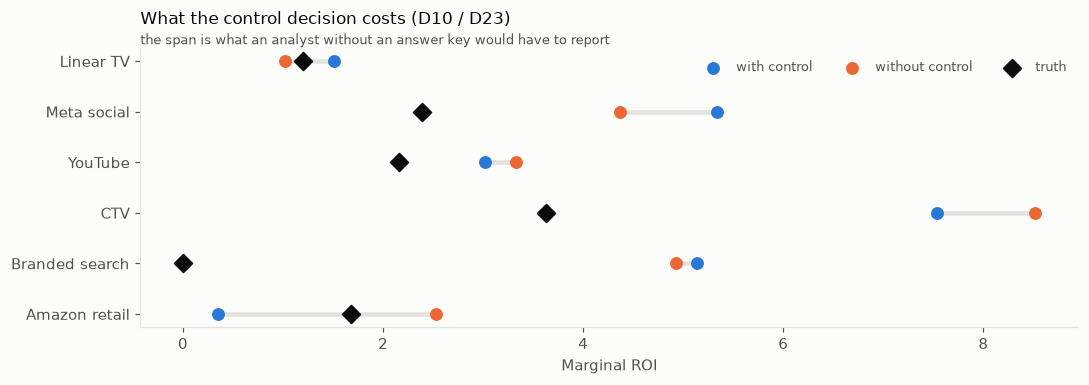

       channel  truth  with_control  without_control  span  closer
     Linear TV   1.20          1.51             1.02  0.48 without
   Meta social   2.39          5.34             4.37  0.96 without
       YouTube   2.16          3.02             3.32  0.30    with
           CTV   3.63          7.54             8.52  0.98    with
Branded search   0.00          5.14             4.93  0.21 without
 Amazon retail   1.67          0.35             2.53  2.18 without

control version closer to truth on 2 of 6 channels


In [7]:
Wo = R["without_control"]
cmp = pd.DataFrame([{
    "channel": LABEL[c], "truth": T[c]["true_marginal_roi"],
    "with_control": W["estimates"][c]["mroi"],
    "without_control": Wo["estimates"][c]["mroi"],
} for c in CH])
cmp["span"] = (cmp.with_control - cmp.without_control).abs()

fig, ax = plt.subplots(figsize=(10, 3.6))
yv = np.arange(len(cmp))
ax.hlines(yv, cmp.without_control, cmp.with_control, color=GRID, linewidth=3)
ax.scatter(cmp.with_control, yv, s=55, color=BLUE, label="with control", zorder=3)
ax.scatter(cmp.without_control, yv, s=55, color=ORANGE, label="without control", zorder=3)
ax.scatter(cmp.truth, yv, s=70, color=INK, marker="D", label="truth", zorder=4)
ax.set_yticks(yv); ax.set_yticklabels(cmp.channel); ax.invert_yaxis()
ax.legend(frameon=False, fontsize=8.5, ncol=3, labelcolor=INK2); ax.grid(axis="y", visible=False)
tidy(ax, "What the control decision costs (D10 / D23)",
     "the span is what an analyst without an answer key would have to report", "")
ax.set_xlabel("Marginal ROI"); plt.tight_layout(); plt.show()

cmp["closer"] = np.where((cmp.with_control - cmp.truth).abs()
                         < (cmp.without_control - cmp.truth).abs(), "with", "without")
print(cmp.round(2).to_string(index=False))
print(f"\ncontrol version closer to truth on {int((cmp.closer=='with').sum())} of {len(cmp)} channels")

**Your read:**



---
## Where this leaves us

Fill in once the sections above are worked through. Anything that becomes a
project decision goes to `DECISIONS.md`, and the conclusions belong in
`07-evaluation.md`.